# House Price Analysis

This notebook is the main EDA notebook for the house price project. Its job is to help you decide **what to inspect next**, **which features deserve manual review**, and **what preprocessing should happen to each feature** before you lock it into an experiment.

The notebook is intentionally tied to the shared code in `src/`, so the visuals here match the preprocessing and experiment logic used by the scripts.


## 1. Setup

We import the local project modules, reload them inside Jupyter so changes in `src/` appear immediately, and then load the dataset using the same configuration that the experiment runner uses.


In [86]:
from pathlib import Path
import sys
import importlib

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'task-house-prices':
    NOTEBOOK_DIR = Path('/Users/maksymponomarenko/Documents/ai-engineering-kaggle-portfolio/courses/01-machine-learning-with-python/tasks/task-house-prices')

SRC_DIR = NOTEBOOK_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config as config_module
import evaluate as evaluate_module
import experiment_config as experiment_config_module
import experiment_runner as experiment_runner_module
import feature_analysis as feature_analysis_module
import feature_registry as feature_registry_module
import preprocessing as preprocessing_module
import processing_config as processing_config_module
import reporting as reporting_module
import train as train_module
import utils as utils_module

for module in [
    config_module,
    evaluate_module,
    experiment_config_module,
    experiment_runner_module,
    feature_analysis_module,
    feature_registry_module,
    preprocessing_module,
    processing_config_module,
    reporting_module,
    train_module,
    utils_module,
]:
    importlib.reload(module)

from config import CONFIG
from evaluate import compare_models, compute_permutation_importance
from experiment_config import ExperimentConfig, project_config_from_experiment
from experiment_runner import apply_feature_builders
from feature_analysis import categorical_cardinality_table, missingness_table, skewness_table
from feature_registry import CATEGORICAL_FEATURES, NUMERIC_FEATURES, ORDINAL_FEATURES
from processing_config import CategoricalProcessingConfig, NumericProcessingConfig, OrdinalProcessingConfig
from reporting import (
    build_after_processing_preview,
    build_before_processing_report,
    build_column_processing_summary,
    build_feature_selection_report,
    build_full_transformed_dataframe,
    build_processing_reference_report,
    transformed_columns_for_source,
)
from utils import (
    collect_configured_features,
    ensure_directories,
    load_datasets,
    split_features_target,
    validate_feature_groups,
    validate_required_columns,
)


### Notebook analysis configuration

This notebook defaults to an **all-features analysis view**. You can edit this experiment definition directly in the notebook to try different feature groups, add engineered columns, or override processing for specific columns.


In [87]:
analysis_experiment = ExperimentConfig(
    name="4 - HasGarage: GarageArea >0",
    description="HasGarage = GarageArea >0",
    feature_groups=["numeric_core", "ordinal_core", "categorical_core"],
    derived_feature_groups=["engineered_core"],
    add_columns=["TotalSF", "HouseAge", "TotalBathrooms", 
                #  "GarageAreaPerCar"],
                 "HasGarage"],
                #  ],
    drop_columns=["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "GarageCars"],
    model_names=["linear_regression", "ridge", "random_forest"],
    numeric_processing_overrides={
        "LotArea": NumericProcessingConfig(impute_strategy="median", transform="log1p", scale="standard"),
        "GrLivArea": NumericProcessingConfig(impute_strategy="median", transform="log1p", scale="standard"),
        "HouseAge": NumericProcessingConfig(impute_strategy="median", transform="none", scale="standard"),
        "TotalSF": NumericProcessingConfig(impute_strategy="median", transform="none", scale="quantile"),
        # "GarageAreaPerCar": NumericProcessingConfig(impute_strategy="constant", fill_value=0, transform="log1p", scale="quantile"),
        "GarageArea": NumericProcessingConfig(impute_strategy="constant", fill_value=0, transform="none", scale="quantile"),
        "HasGarage": NumericProcessingConfig(impute_strategy="constant", fill_value=0, transform="none", scale="none"),
    },
    categorical_processing_overrides={
        "Neighborhood": CategoricalProcessingConfig(impute_strategy="most_frequent", encoding="onehot", min_frequency=0.01),
    },
    ordinal_processing_overrides={
        "KitchenQual": OrdinalProcessingConfig(impute_strategy="constant", fill_value="__MISSING__", encoding="explicit_ordinal"),
    },
)


preview_model_name = 'ridge'
analysis_experiment

ExperimentConfig(name='4 - HasGarage: GarageArea >0', description='HasGarage = GarageArea >0', feature_groups=['numeric_core', 'ordinal_core', 'categorical_core'], add_columns=['TotalSF', 'HouseAge', 'TotalBathrooms', 'HasGarage'], drop_columns=['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GarageCars'], derived_feature_groups=['engineered_core'], derived_features=[], log_transform_columns=None, target_transform=None, numeric_processing_overrides={'LotArea': NumericProcessingConfig(impute_strategy='median', fill_value=None, transform='log1p', scale='standard'), 'GrLivArea': NumericProcessingConfig(impute_strategy='median', fill_value=None, transform='log1p', scale='standard'), 'HouseAge': NumericProcessingConfig(impute_strategy='median', fill_value=None, transform='none', scale='standard'), 'TotalSF': NumericProcessingConfig(impute_strategy='median', fill_value=None, transform='none', scale='quantile'), 'GarageArea': NumericProcessingConfig(impute_strategy='constant', fill_value=0, transform

In [88]:
ensure_directories(CONFIG)
train_df, test_df = load_datasets(CONFIG)

derived_feature_names = analysis_experiment.derived_features.copy()
for feature_name in analysis_experiment.derived_feature_groups:
    pass

from experiment_config import resolve_derived_features

derived_feature_names = resolve_derived_features(
    analysis_experiment.derived_feature_groups,
    analysis_experiment.derived_features,
)

train_augmented = apply_feature_builders(train_df, derived_feature_names)
test_augmented = apply_feature_builders(test_df, derived_feature_names) if test_df is not None else None

analysis_config = project_config_from_experiment(CONFIG, analysis_experiment)
selected_features = collect_configured_features(analysis_config)

validate_required_columns(
    train_augmented,
    [analysis_config.target_column, *selected_features],
    dataset_name='train dataset',
)
validate_feature_groups(analysis_config, train_augmented.columns)

if test_augmented is not None:
    validate_required_columns(
        test_augmented,
        selected_features,
        dataset_name='test dataset',
    )

print(f'Train shape: {train_augmented.shape}')
print(f'Test shape: {None if test_augmented is None else test_augmented.shape}')
print(f'Selected feature count: {len(selected_features)}')
print(f'Preview model for processing summaries: {preview_model_name}')
train_augmented.head()

Train shape: (1460, 85)
Test shape: (1459, 84)
Selected feature count: 28
Preview model for processing summaries: ridge


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,HouseAge,TotalBathrooms,HasGarage
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,2566,5,3.5,1
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,2524,31,2.5,1
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,2706,7,3.5,1
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,2473,91,2.0,1
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,3343,8,3.5,1


In [89]:
train_augmented.dtypes.sort_index().head(100)

1stFlrSF            int64
2ndFlrSF            int64
3SsnPorch           int64
Alley              object
BedroomAbvGr        int64
BldgType           object
BsmtCond           object
BsmtExposure       object
BsmtFinSF1          int64
BsmtFinSF2          int64
BsmtFinType1       object
BsmtFinType2       object
BsmtFullBath        int64
BsmtHalfBath        int64
BsmtQual           object
BsmtUnfSF           int64
CentralAir         object
Condition1         object
Condition2         object
Electrical         object
EnclosedPorch       int64
ExterCond          object
ExterQual          object
Exterior1st        object
Exterior2nd        object
Fence              object
FireplaceQu        object
Fireplaces          int64
Foundation         object
FullBath            int64
Functional         object
GarageArea          int64
GarageCars          int64
GarageCond         object
GarageFinish       object
GarageQual         object
GarageType         object
GarageYrBlt       float64
GrLivArea   

In [90]:
missingness_table(train_augmented).head(20)

,missing_count,missing_percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


## 2. Problem framing

This is a **supervised regression** problem. We observe house features and predict a continuous target, usually `SalePrice`.

The notebook keeps three metrics in view:

- **RMSE**: emphasizes larger mistakes more strongly.
- **MAE**: average absolute error in the original target units.
- **R²**: how much variance the model explains compared with a mean baseline.

Cross-validation matters because a single split can flatter or punish a model by chance.


In [91]:
print(f'Target column: {analysis_config.target_column}')
print(f'Target transform: {analysis_config.target_transform}')
print(f'Models in this notebook view: {analysis_experiment.model_names}')

Target column: SalePrice
Target transform: log1p
Models in this notebook view: ['linear_regression', 'ridge', 'random_forest']


## 3. Target analysis

Inspecting the target first helps us decide whether a target transform such as `log1p(target)` is sensible. In predictive ML, we care less about perfect normality and more about whether the target scale makes learning and evaluation more stable.


Target skewness: 1.883
log1p(target) skewness: 0.121


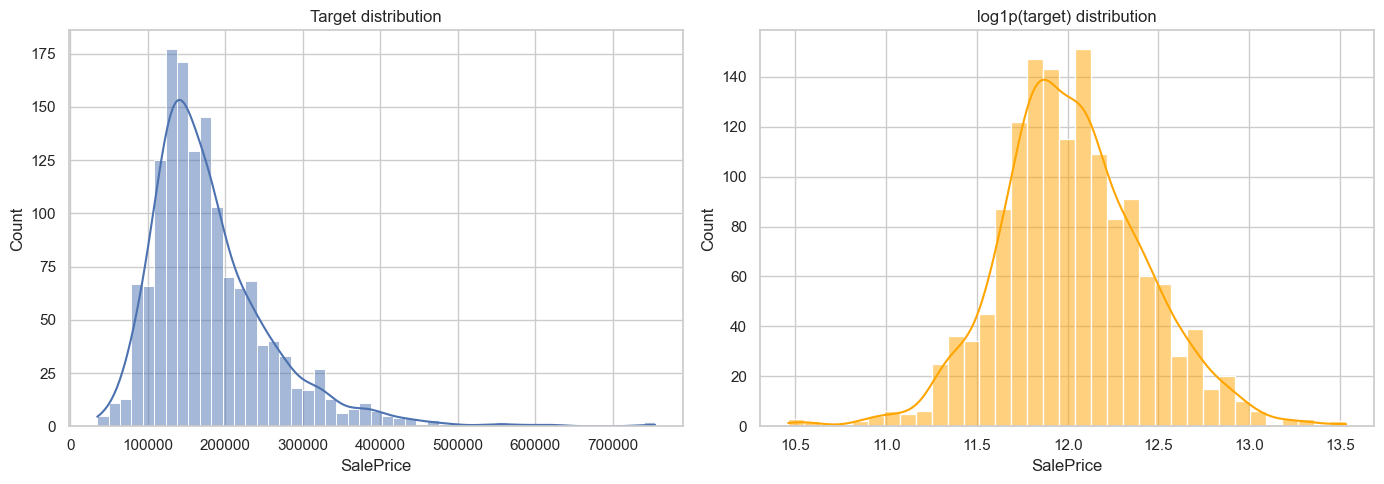

In [92]:
target = train_augmented[analysis_config.target_column]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(target, kde=True, ax=axes[0])
axes[0].set_title('Target distribution')
sns.histplot(np.log1p(target), kde=True, color='orange', ax=axes[1])
axes[1].set_title('log1p(target) distribution')
plt.tight_layout()

print('Target skewness:', round(target.skew(), 3))
print('log1p(target) skewness:', round(np.log1p(target).skew(), 3))

## 4. Feature organization

This section is the main control panel for feature inspection. It shows which columns are active in this notebook, which derived features were added, and which original features are currently left out.


In [93]:
numeric_features = analysis_config.numeric_features.copy()
categorical_features = analysis_config.categorical_features.copy()
ordinal_features = analysis_config.ordinal_features.copy()

print('Numeric feature count:', len(numeric_features))
print('Categorical feature count:', len(categorical_features))
print('Ordinal feature count:', len(ordinal_features))
print('Derived features added for this notebook:', derived_feature_names)

Numeric feature count: 13
Categorical feature count: 7
Ordinal feature count: 8
Derived features added for this notebook: ['TotalSF', 'HouseAge', 'TotalBathrooms', 'HasGarage']


In [94]:
feature_selection_report = build_feature_selection_report(analysis_config, preview_model_name)
feature_selection_report['used_features_with_processing'].head(100)

,column,feature_type,impute_strategy,transform,scale,encoding,notes,is_used
0,BldgType,categorical,most_frequent,none,none,onehot,min_frequency=None; alternatives include const...,True
1,Foundation,categorical,most_frequent,none,none,onehot,min_frequency=None; alternatives include const...,True
2,GarageType,categorical,most_frequent,none,none,onehot,min_frequency=None; alternatives include const...,True
3,HouseStyle,categorical,most_frequent,none,none,onehot,min_frequency=None; alternatives include const...,True
4,MSZoning,categorical,most_frequent,none,none,onehot,min_frequency=None; alternatives include const...,True
5,Neighborhood,categorical,most_frequent,none,none,onehot,min_frequency=0.01; alternatives include const...,True
6,SaleCondition,categorical,most_frequent,none,none,onehot,min_frequency=None; alternatives include const...,True
7,Fireplaces,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ...",True
8,FullBath,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ...",True
9,GarageArea,numeric,constant,none,quantile,none,"Default numeric alternatives: mean, most_frequ...",True


In [95]:
feature_selection_report['unused_numeric_features']

,column
0,1stFlrSF
1,2ndFlrSF
2,3SsnPorch
3,BedroomAbvGr
4,BsmtFinSF1
5,BsmtFinSF2
6,BsmtFullBath
7,BsmtHalfBath
8,BsmtUnfSF
9,EnclosedPorch


In [96]:
feature_selection_report['unused_categorical_features']

,column
0,Alley
1,Condition1
2,Condition2
3,Electrical
4,Exterior1st
5,Exterior2nd
6,Heating
7,LandContour
8,LotConfig
9,MSSubClass


In [97]:
feature_selection_report['unused_ordinal_features']

,column
0,BsmtCond
1,BsmtExposure
2,BsmtFinType1
3,BsmtFinType2
4,CentralAir
5,ExterCond
6,Fence
7,FireplaceQu
8,GarageCond
9,GarageQual


## 5. Processing design reference

Before looking at plots, it helps to know what the current preprocessing defaults are, what alternatives exist, and what the notebook is actually doing for each active column.

The point is not that one default is always best. The point is to make the choices explicit so you can change them intentionally.


In [98]:
processing_reference = build_processing_reference_report()
processing_reference['numeric_processing_reference']

,setting,default,alternatives,when_to_use
0,impute_strategy,median,"mean, most_frequent, constant",median is robust to outliers; mean is reasonab...
1,transform,none,"log1p, sqrt",log1p helps right-skewed positive features; sq...
2,scale,none or standard depending on model,"standard, robust, none",standard for linear models; robust when outlie...


In [99]:
processing_reference['categorical_processing_reference']

,setting,default,alternatives,when_to_use
0,impute_strategy,most_frequent,constant,most_frequent is simple; constant is useful wh...
1,encoding,onehot,documented only,one-hot is the safest default for nominal cate...
2,min_frequency,None,float or int threshold,helps merge rare levels when one-hot columns b...


In [100]:
processing_reference['ordinal_processing_reference']

,setting,default,alternatives,when_to_use
0,impute_strategy,constant,most_frequent,constant with __MISSING__ is safest when missi...
1,encoding,explicit_ordinal,documented only,ordinal features need an explicit order; wrong...


In [101]:
processing_summary = build_column_processing_summary(analysis_config, preview_model_name)
processing_summary.head(120)

,column,feature_type,impute_strategy,transform,scale,encoding,notes
0,LotArea,numeric,median,log1p,standard,none,"Default numeric alternatives: mean, most_frequ..."
1,GrLivArea,numeric,median,log1p,standard,none,"Default numeric alternatives: mean, most_frequ..."
2,FullBath,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ..."
3,HalfBath,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ..."
4,TotRmsAbvGrd,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ..."
5,Fireplaces,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ..."
6,GarageArea,numeric,constant,none,quantile,none,"Default numeric alternatives: mean, most_frequ..."
7,YearBuilt,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ..."
8,YearRemodAdd,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ..."
9,TotalSF,numeric,median,none,quantile,none,"Default numeric alternatives: mean, most_frequ..."


## 6. Missing value analysis

Missingness should be inspected before modeling, especially for housing data where missing can be structural rather than random. For example, no pool, no fence, or no alley can be informative rather than simply bad data.

We avoid dropping large chunks of rows silently. Instead, we inspect missingness and decide how each feature should be handled.


In [102]:
before_report = build_before_processing_report(
    train_augmented[selected_features + [analysis_config.target_column]],
    numeric_features,
    categorical_features,
    ordinal_features,
)

before_report['missingness'].head(30)

,missing_count,missing_percent
GarageType,81,5.547945
GarageFinish,81,5.547945
BsmtQual,37,2.534247


<Figure size 1000x800 with 0 Axes>

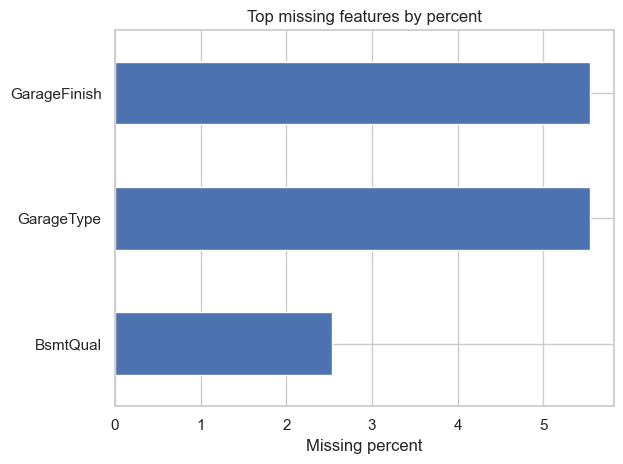

In [103]:
plt.figure(figsize=(10, 8))
missing_plot_df = before_report['missingness'].head(20).sort_values('missing_percent')
missing_plot_df.plot.barh(y='missing_percent', legend=False)
plt.title('Top missing features by percent')
plt.xlabel('Missing percent')
plt.tight_layout()

## 7. Numeric feature analysis

For predictive ML, formal normality tests are usually not central. They often reject large samples for small deviations that do not matter much for prediction.

What matters more in practice:

- skewness that makes relationships harder to model
- outliers that distort linear fits
- whether a transformation improves validation metrics
- whether the feature is useful together with other features


In [104]:
numeric_summary = before_report['numeric_summary']
numeric_summary.head(20)

,count,mean,std,min,25%,50%,75%,max
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.50,215245.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.5,1464.0,1776.75,5642.0
FullBath,1460.0,1.565068,0.550916,0.0,1.0,2.0,2.00,3.0
HalfBath,1460.0,0.382877,0.502885,0.0,0.0,0.0,1.00,2.0
TotRmsAbvGrd,1460.0,6.517808,1.625393,2.0,5.0,6.0,7.00,14.0
Fireplaces,1460.0,0.613014,0.644666,0.0,0.0,1.0,1.00,3.0
GarageArea,1460.0,472.980137,213.804841,0.0,334.5,480.0,576.00,1418.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.0,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.0,1994.0,2004.00,2010.0
TotalSF,1460.0,2567.048630,821.714421,334.0,2009.5,2474.0,3004.00,11752.0


In [105]:
numeric_skewness = before_report['numeric_skewness']
numeric_skewness.head(25)

,feature,skewness
0,LotArea,12.207688
1,HasGarage,-3.887735
2,TotalSF,1.776700
3,GrLivArea,1.366560
4,TotRmsAbvGrd,0.676341
5,HalfBath,0.675897
6,Fireplaces,0.649565
7,YearBuilt,-0.613461
8,HouseAge,0.609030
9,YearRemodAdd,-0.503562


In [106]:
candidate_log_features = numeric_skewness.loc[numeric_skewness['skewness'].abs() > 1.0, 'feature'].tolist()
print('Candidate skewed numeric features for manual transform review:')
print(candidate_log_features)
print('\nConfigured log-transform columns in this notebook config:')
print(analysis_config.log_transform_columns)

Candidate skewed numeric features for manual transform review:
['LotArea', 'HasGarage', 'TotalSF', 'GrLivArea']

Configured log-transform columns in this notebook config:
['LotArea', 'GrLivArea']


In [107]:
target_corr = (
    train_augmented[numeric_features + [analysis_config.target_column]]
    .corr(numeric_only=True)[analysis_config.target_column]
    .sort_values(ascending=False)
)
target_corr.to_frame(name='corr_with_target').head(25)

,corr_with_target
SalePrice,1.000000
TotalSF,0.782260
GrLivArea,0.708624
TotalBathrooms,0.631731
GarageArea,0.623431
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101
Fireplaces,0.466929


In [108]:
def inspect_numeric_feature(column_name: str, transformed_df: pd.DataFrame | None = None, bins: int = 30) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.histplot(train_augmented[column_name].dropna(), kde=True, bins=bins, ax=axes[0, 0])
    axes[0, 0].set_title(f'{column_name}: histogram before processing')

    sns.boxplot(x=train_augmented[column_name], ax=axes[0, 1])
    axes[0, 1].set_title(f'{column_name}: boxplot before processing')

    sns.scatterplot(x=train_augmented[column_name], y=target, alpha=0.5, ax=axes[1, 0])
    axes[1, 0].set_title(f'{column_name}: relationship with target')

    if transformed_df is not None:
        transformed_columns = transformed_columns_for_source(column_name, transformed_df.columns.tolist())
        if transformed_columns:
            sns.histplot(transformed_df[transformed_columns[0]].dropna(), kde=True, bins=bins, color='darkorange', ax=axes[1, 1])
            axes[1, 1].set_title(f'{transformed_columns[0]}: histogram after processing')
        else:
            axes[1, 1].text(0.5, 0.5, 'No transformed column found', ha='center', va='center')
            axes[1, 1].set_title('After processing preview')
    else:
        axes[1, 1].text(0.5, 0.5, 'Pass transformed_df to compare before and after', ha='center', va='center')
        axes[1, 1].set_title('After processing preview')

    plt.tight_layout()

In [109]:
X, y = split_features_target(train_augmented, analysis_config)
transformed_df = build_full_transformed_dataframe(X, analysis_config, preview_model_name)
print('Transformed matrix shape:', transformed_df.shape)
transformed_df.head()

Transformed matrix shape: (1460, 80)


,LotArea,GrLivArea,FullBath,HalfBath,TotRmsAbvGrd,Fireplaces,YearBuilt,YearRemodAdd,HouseAge,TotalBathrooms,GarageArea,TotalSF,HasGarage,Neighborhood_Blmngtn,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_infrequent_sklearn,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,LotShape,ExterQual,BsmtQual,HeatingQC,Functional,GarageFinish,PavedDrive,KitchenQual
0,-0.133270,0.529194,0.789741,1.227585,0.912210,-0.951226,1.050994,0.878668,-1.043259,1.642256,0.682683,0.546379,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,4.0,4.0,5.0,8.0,2.0,3.0,4.0
1,0.113413,-0.381965,0.789741,-0.761621,-0.318683,0.600495,0.156734,-0.429577,-0.183465,0.368581,0.456456,0.527528,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,3.0,4.0,5.0,8.0,2.0,3.0,3.0
2,0.420049,0.659631,0.789741,1.227585,-0.318683,0.600495,0.984752,0.830215,-0.977121,1.642256,0.787788,0.614756,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,4.0,4.0,5.0,8.0,2.0,3.0,4.0
3,0.103317,0.541448,-1.026041,-0.761621,0.296763,0.600495,-1.863632,-0.720298,1.800676,-0.268257,0.820320,0.499499,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,3.0,4.0,8.0,1.0,3.0,4.0
4,0.878431,1.282295,0.789741,1.227585,1.527656,0.600495,0.951632,0.733308,-0.944052,1.642256,0.939940,0.850976,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,4.0,4.0,5.0,8.0,2.0,3.0,4.0


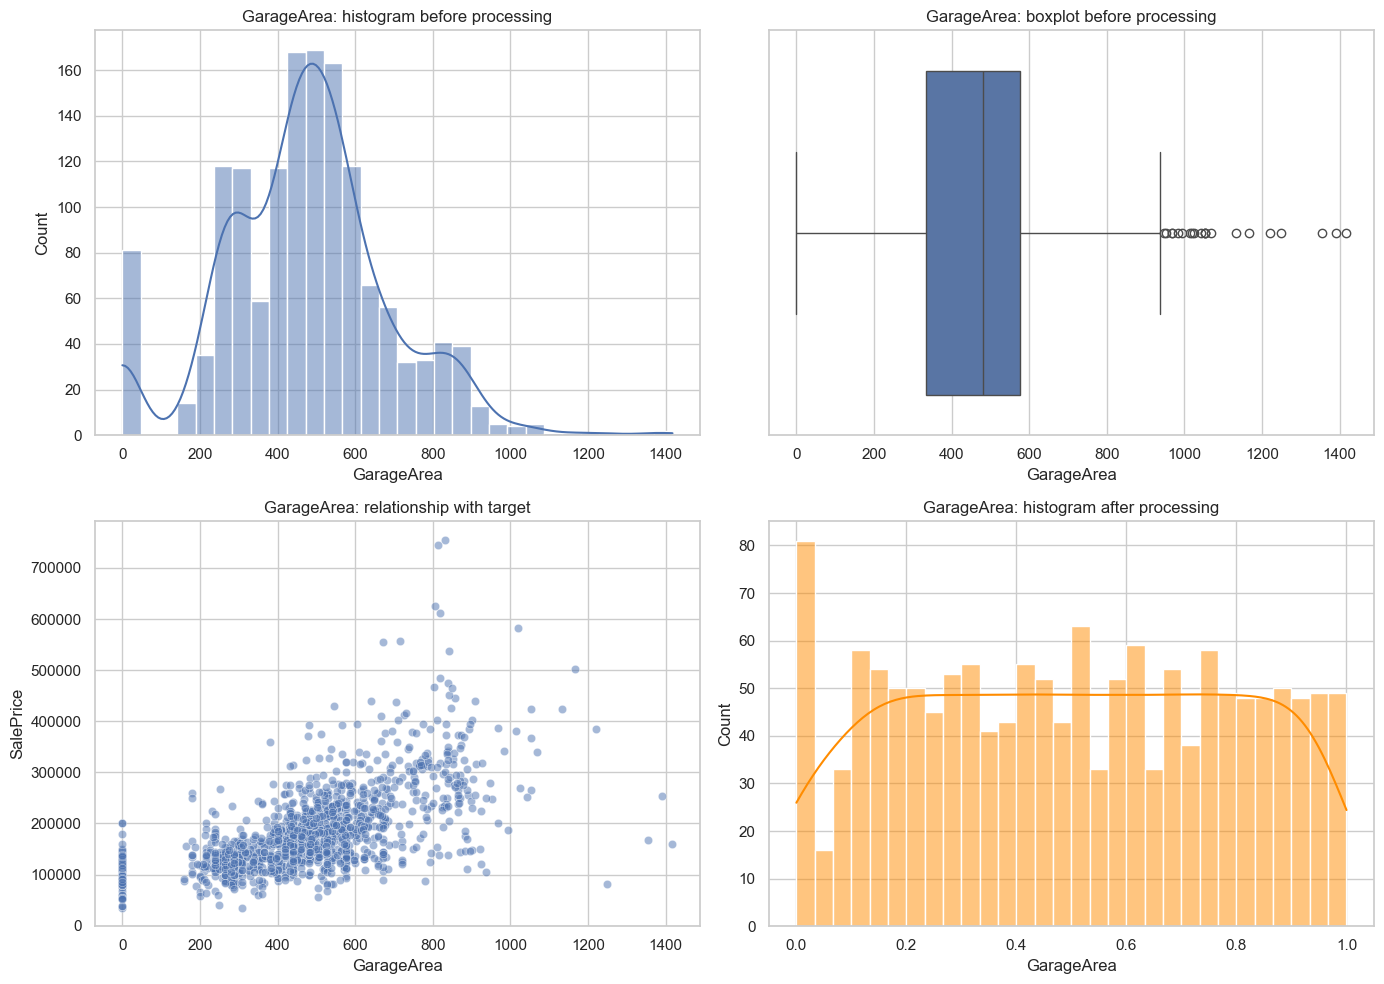

In [110]:
inspect_numeric_feature('GarageArea', transformed_df=transformed_df)
# plot_numeric_before_after("GarageAreaPerCar")


In [111]:
# inspect_numeric_feature('LotArea', transformed_df=transformed_df)

## 8. Categorical feature analysis

For nominal categorical features, grouped target statistics and boxplots are usually more informative than trying to force a numeric ranking.

A feature with overlapping medians is not automatically useless. It may still matter through interactions, local effects, or nonlinear structure.


In [112]:
categorical_cardinality = before_report['categorical_cardinality']
categorical_cardinality.head(25)

,feature,n_unique,missing_count
0,Neighborhood,25,0
1,HouseStyle,8,0
2,GarageType,7,81
3,Foundation,6,0
4,SaleCondition,6,0
5,MSZoning,5,0
6,BldgType,5,0


In [113]:
def inspect_categorical_feature(column_name: str, top_n: int = 12) -> None:
    counts = train_augmented[column_name].fillna('__MISSING__').value_counts().head(top_n)
    ordered_levels = counts.index.tolist()
    grouped = (
        train_augmented.assign(_feature=train_augmented[column_name].fillna('__MISSING__'))
        .groupby('_feature')[analysis_config.target_column]
        .agg(['count', 'median', 'mean'])
        .sort_values('median', ascending=False)
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.countplot(
        data=train_augmented.assign(_feature=train_augmented[column_name].fillna('__MISSING__')),
        y='_feature',
        order=counts.index,
        ax=axes[0],
    )
    axes[0].set_title(f'{column_name}: top levels by count')
    axes[0].set_ylabel(column_name)

    plot_order = grouped.head(top_n).index.tolist()
    sns.boxplot(
        data=train_augmented.assign(_feature=train_augmented[column_name].fillna('__MISSING__')),
        x=analysis_config.target_column,
        y='_feature',
        order=plot_order,
        ax=axes[1],
    )
    axes[1].set_title(f'{column_name}: target by category')
    axes[1].set_ylabel(column_name)

    plt.tight_layout()
    display(grouped.head(20))

,count,median,mean
_feature,,,
NridgHt,77,315000.0,316270.623377
NoRidge,41,301500.0,335295.317073
StoneBr,25,278000.0,310499.000000
Timber,38,228475.0,242247.447368
Somerst,86,225500.0,225379.837209
Veenker,11,218000.0,238772.727273
Crawfor,51,200624.0,210624.725490
ClearCr,28,200250.0,212565.428571
CollgCr,150,197200.0,197965.773333


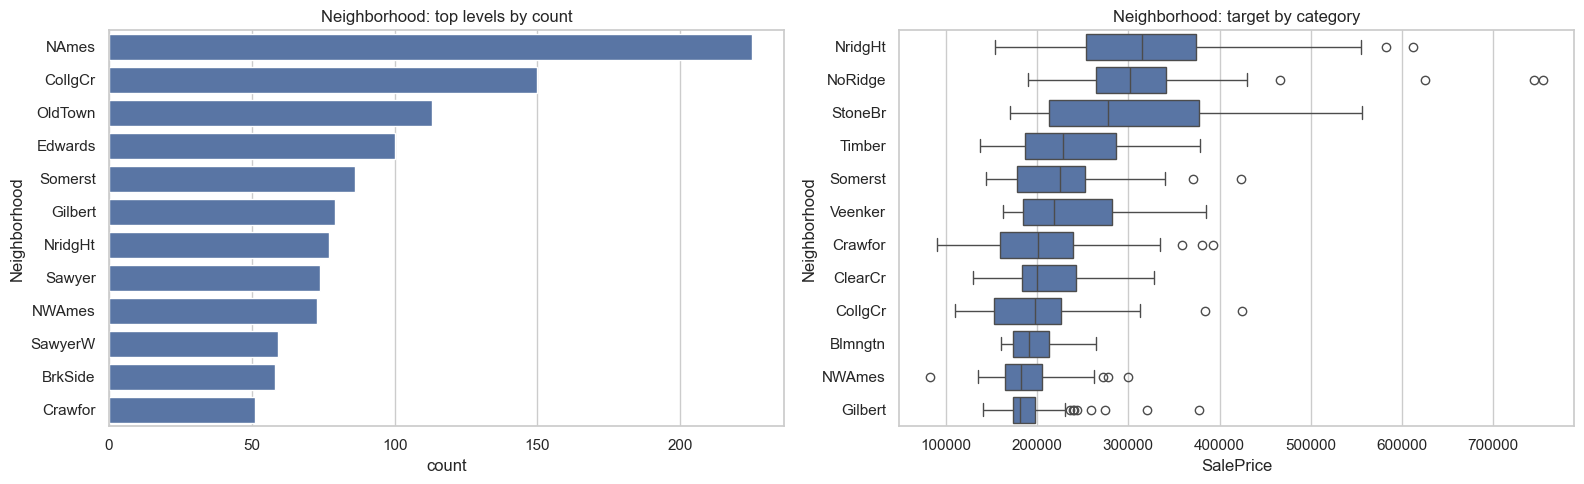

In [114]:
inspect_categorical_feature('Neighborhood')

,count,median,mean
_feature,,,
Partial,125,244600.0,272291.752000
Normal,1198,160000.0,175202.219533
Alloca,12,148145.0,167377.416667
Family,20,140500.0,149600.000000
Abnorml,101,130000.0,146526.623762
AdjLand,4,104000.0,104125.000000


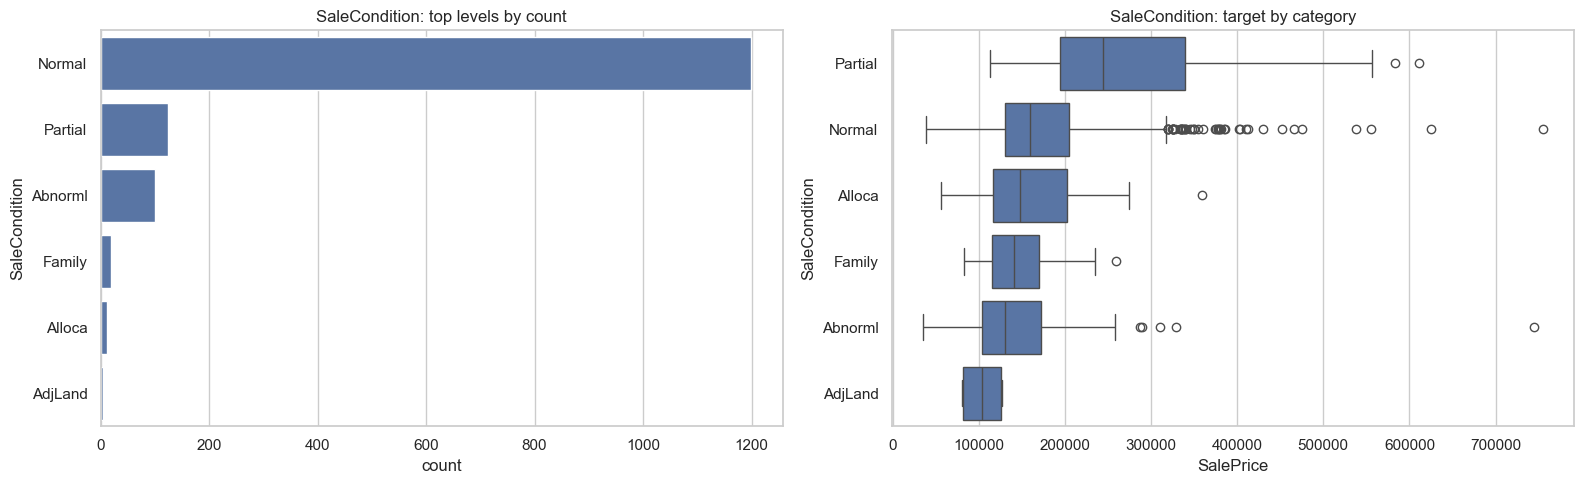

In [115]:
inspect_categorical_feature('SaleCondition')

## 9. Ordinal feature analysis

Ordinal features should be treated differently from nominal features because they carry a meaningful order. The main risk is encoding the order incorrectly.

This section shows the explicit mapping and the empirical target behavior by level so you can sanity-check whether the chosen order still makes sense.


In [116]:
pd.DataFrame({
    feature: pd.Series(mapping).sort_values()
    for feature, mapping in analysis_config.ordinal_mappings.items()
}).head(10)

,LotShape,ExterQual,BsmtQual,HeatingQC,KitchenQual,Functional,GarageFinish,PavedDrive
Ex,NaN,5.0,5.0,5.0,5.0,NaN,NaN,NaN
Fa,NaN,2.0,2.0,2.0,2.0,NaN,NaN,NaN
Fin,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN
Gd,NaN,4.0,4.0,4.0,4.0,NaN,NaN,NaN
IR1,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IR2,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IR3,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Maj1,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
Maj2,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN
Min1,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN


In [117]:
def inspect_ordinal_feature(column_name: str, transformed_df: pd.DataFrame | None = None) -> None:
    mapping = analysis_config.ordinal_mappings[column_name]
    stats = (
        train_augmented.assign(_feature=train_augmented[column_name].fillna('__MISSING__'))
        .groupby('_feature')[analysis_config.target_column]
        .agg(['count', 'median', 'mean'])
    )

    ordered_levels = [level for level, _ in sorted(mapping.items(), key=lambda item: item[1]) if level in stats.index]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.boxplot(
        data=train_augmented.assign(_feature=train_augmented[column_name].fillna('__MISSING__')),
        x='_feature',
        y=analysis_config.target_column,
        order=ordered_levels,
        ax=axes[0],
    )
    axes[0].set_title(f'{column_name}: target by ordinal level')
    axes[0].tick_params(axis='x', rotation=45)

    if transformed_df is not None:
        transformed_columns = transformed_columns_for_source(column_name, transformed_df.columns.tolist())
        if transformed_columns:
            sns.histplot(transformed_df[transformed_columns[0]], bins=20, kde=False, ax=axes[1], color='teal')
            axes[1].set_title(f'{transformed_columns[0]}: encoded distribution')
        else:
            axes[1].text(0.5, 0.5, 'No encoded column found', ha='center', va='center')
            axes[1].set_title('Encoded distribution')
    else:
        axes[1].text(0.5, 0.5, 'Pass transformed_df to inspect encoded output', ha='center', va='center')
        axes[1].set_title('Encoded distribution')

    plt.tight_layout()
    print('Mapping:', mapping)
    display(stats.loc[ordered_levels])

Mapping: {'__MISSING__': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}


,count,median,mean
_feature,,,
__MISSING__,81,100000.0,103317.283951
Unf,605,135000.0,142156.423140
RFn,422,190000.0,202068.869668
Fin,352,215000.0,240052.690341


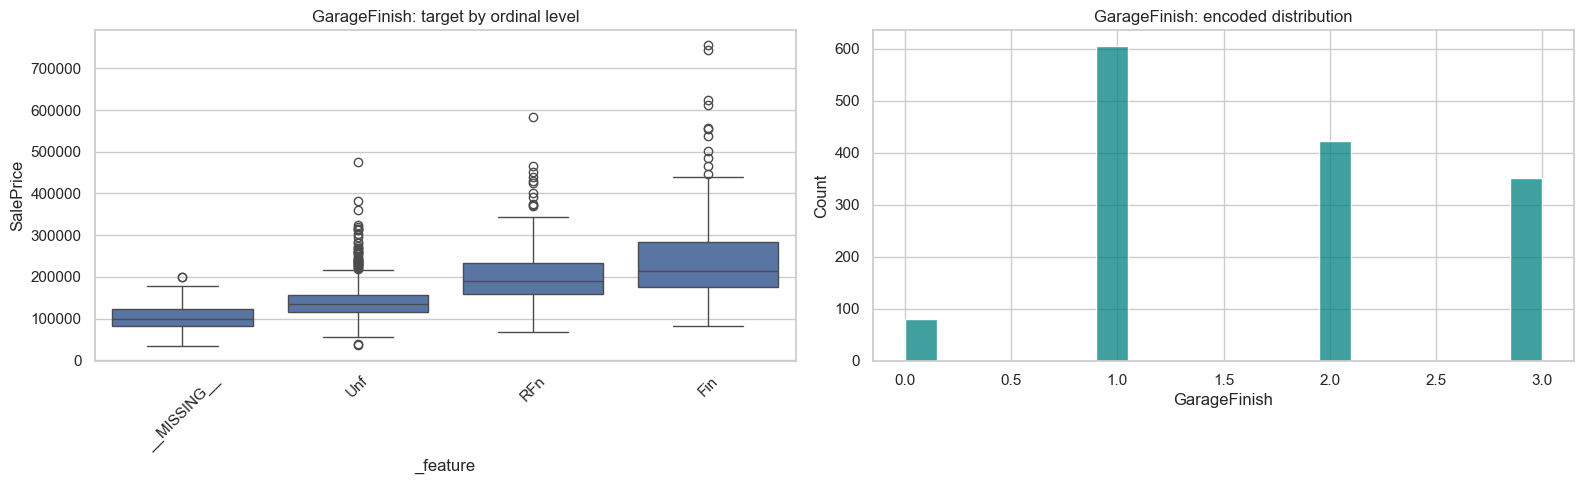

In [118]:
inspect_ordinal_feature('GarageFinish', transformed_df=transformed_df)

Mapping: {'__MISSING__': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}


,count,median,mean
_feature,,,
__MISSING__,37,101800.0,105652.891892
Fa,35,112000.0,115692.028571
TA,649,135500.0,140759.818182
Gd,618,192070.0,202688.478964
Ex,121,318000.0,327041.041322


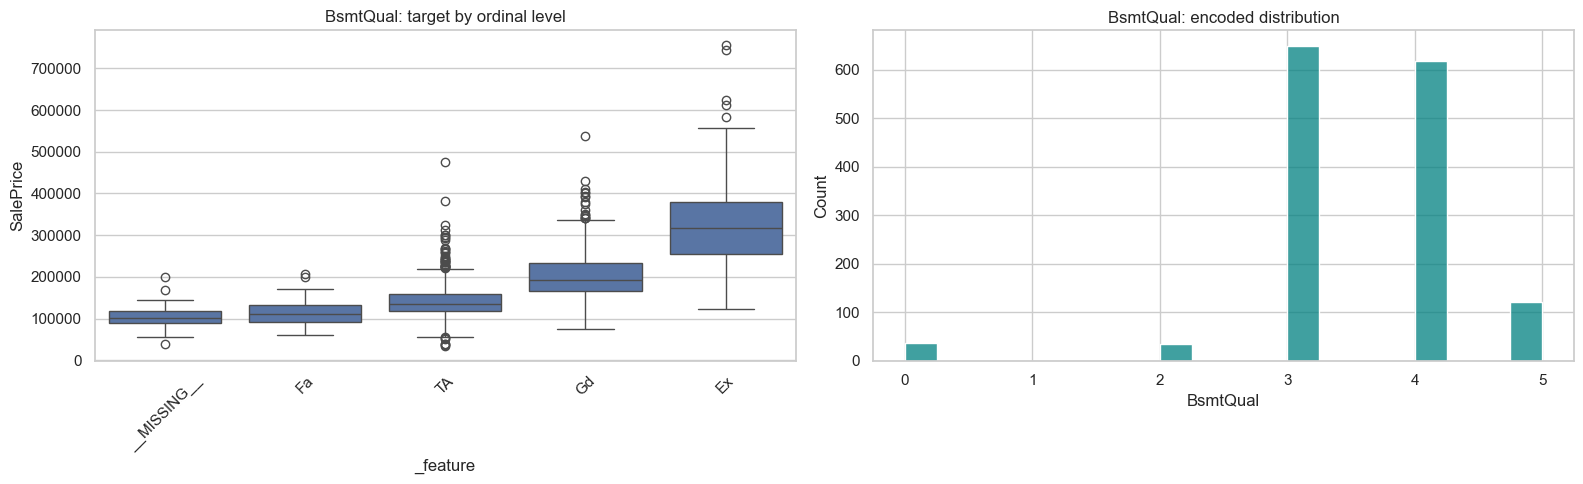

In [119]:
inspect_ordinal_feature('BsmtQual', transformed_df=transformed_df)

## 10. Dependence exploration

Correlation is useful, but it is not enough on its own for feature selection.

Why not:

- a feature can have low linear correlation and still matter through nonlinear structure
- correlated features can still help differently depending on the model
- multicollinearity matters more for interpreting linear coefficients than for tree-based models


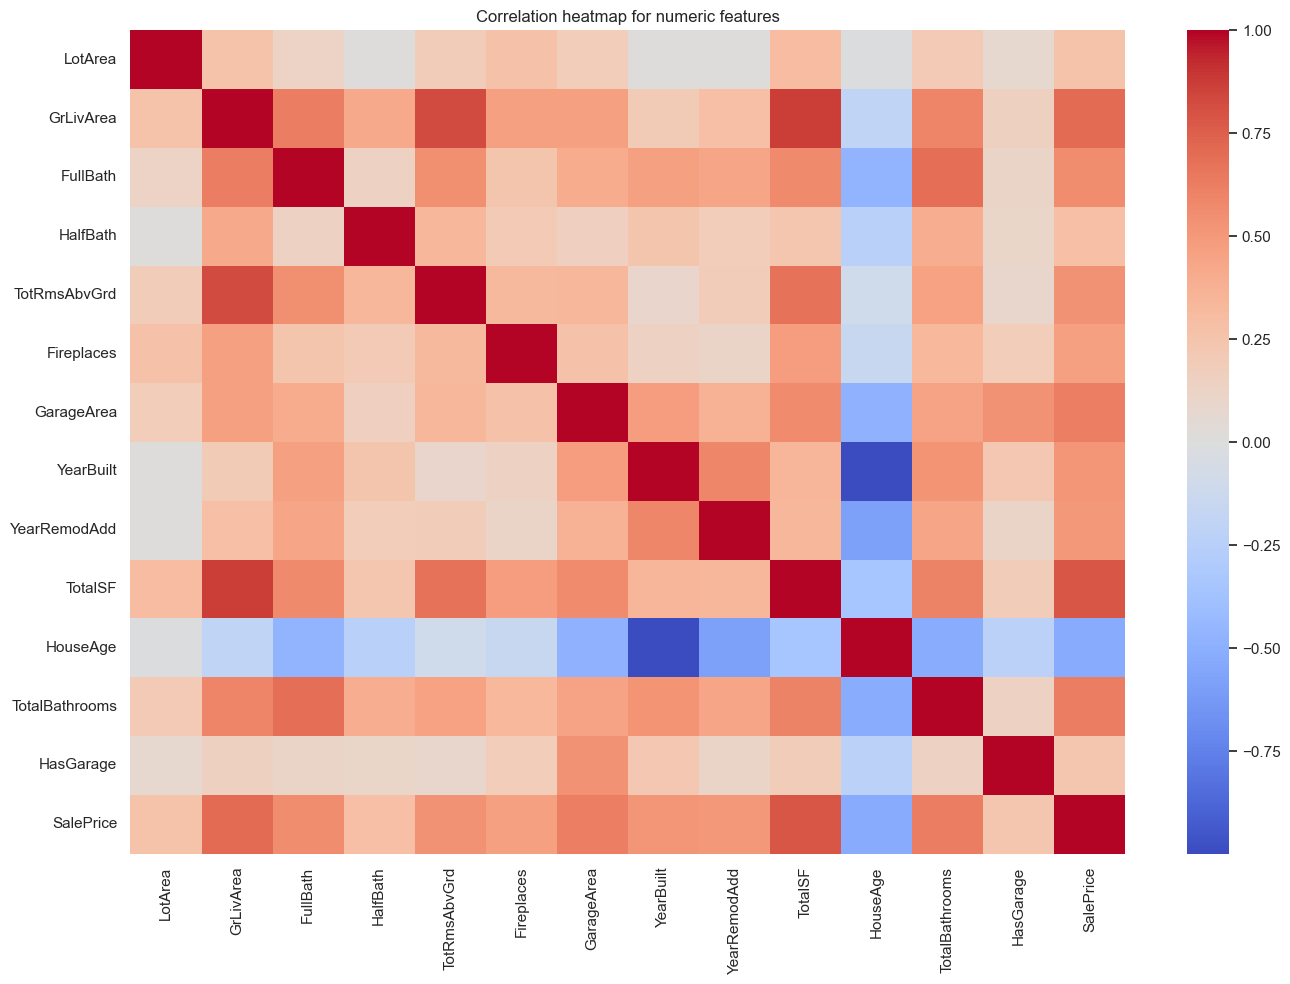

In [120]:
plt.figure(figsize=(14, 10))
correlation_matrix = train_augmented[numeric_features + [analysis_config.target_column]].corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
plt.title('Correlation heatmap for numeric features')
plt.tight_layout()

In [121]:
from sklearn.feature_selection import mutual_info_regression

mi_source = train_augmented[numeric_features].copy()
mi_source = mi_source.fillna(mi_source.median(numeric_only=True))
mi_scores = pd.Series(
    mutual_info_regression(mi_source, target, random_state=analysis_config.random_state),
    index=mi_source.columns,
).sort_values(ascending=False)
mi_scores.head(25).to_frame(name='mutual_information')

,mutual_information
TotalSF,0.676661
GrLivArea,0.480710
GarageArea,0.367878
YearBuilt,0.353519
TotalBathrooms,0.340975
HouseAge,0.339323
YearRemodAdd,0.252067
FullBath,0.244533
TotRmsAbvGrd,0.216376
LotArea,0.159122


## 11. Before and after processing inspection

This is the bridge between raw EDA and model-ready data. The point is to see what preprocessing actually did to a column, not just trust the pipeline blindly.


In [122]:
after_preview = build_after_processing_preview(X, analysis_config, preview_model_name, n_rows=10000)
# after_preview.filter(like="")[after_preview["GarageArea"]==0].head()


In [123]:
source_column = 'Neighborhood'
matched_columns = transformed_columns_for_source(source_column, transformed_df.columns.tolist())
matched_columns[:20]

['Neighborhood_Blmngtn',
 'Neighborhood_BrDale',
 'Neighborhood_BrkSide',
 'Neighborhood_ClearCr',
 'Neighborhood_CollgCr',
 'Neighborhood_Crawfor',
 'Neighborhood_Edwards',
 'Neighborhood_Gilbert',
 'Neighborhood_IDOTRR',
 'Neighborhood_MeadowV',
 'Neighborhood_Mitchel',
 'Neighborhood_NAmes',
 'Neighborhood_NWAmes',
 'Neighborhood_NoRidge',
 'Neighborhood_NridgHt',
 'Neighborhood_OldTown',
 'Neighborhood_SWISU',
 'Neighborhood_Sawyer',
 'Neighborhood_SawyerW',
 'Neighborhood_Somerst']

In [124]:
source_column = 'Neighborhood'
matched_columns = transformed_columns_for_source(source_column, transformed_df.columns.tolist())
if matched_columns:
    transformed_df[matched_columns].sum().sort_values(ascending=False).head(15).to_frame(name='encoded_sum')
else:
    pd.DataFrame({'message': ['No transformed columns found']})

## 12. Model comparison for this notebook configuration

Feature inspection should feed experiments, but it is still useful to see how the current configuration behaves across several models. The goal here is not to declare a final winner forever. The goal is to understand how the same feature set interacts with different model families.


In [125]:
comparison_df = compare_models(analysis_experiment.model_names, X, y, analysis_config)
comparison_df

,model_name,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,random_forest,31419.110541,7130.437541,18064.900533,1604.813539,0.829876,0.096175
1,ridge,32376.403938,7469.541135,17901.900212,982.005245,0.818707,0.106030
2,linear_regression,32422.511300,7003.641587,18123.675871,1029.544771,0.819903,0.097420


## 13. Permutation importance

Permutation importance is often more useful for predictive workflows than ANOVA or t-tests because it checks whether a feature helps **inside the fitted model context**.

Important interpretation notes:

- near-zero importance means the model may not rely much on the feature right now
- negative importance can happen because of noise or redundancy
- low importance is not an automatic deletion rule
- a weak standalone feature can still help in combination with others


In [126]:
best_model_name = comparison_df.loc[0, 'model_name']
importance_df = compute_permutation_importance(best_model_name, X, y, analysis_config, n_repeats=15)
importance_df.head(25)

,feature,importance_mean,importance_std
0,TotalSF,43657.331185,2376.367519
1,KitchenQual,5858.276883,1407.977543
2,YearRemodAdd,3735.204505,958.171577
3,GarageArea,2677.485227,264.111109
4,ExterQual,2466.296521,731.435314
5,BsmtQual,2460.606453,197.932718
6,LotArea,1854.313181,332.002188
7,YearBuilt,1454.257946,229.730205
8,HouseAge,1414.423961,223.386530
9,TotalBathrooms,1169.982207,287.936705


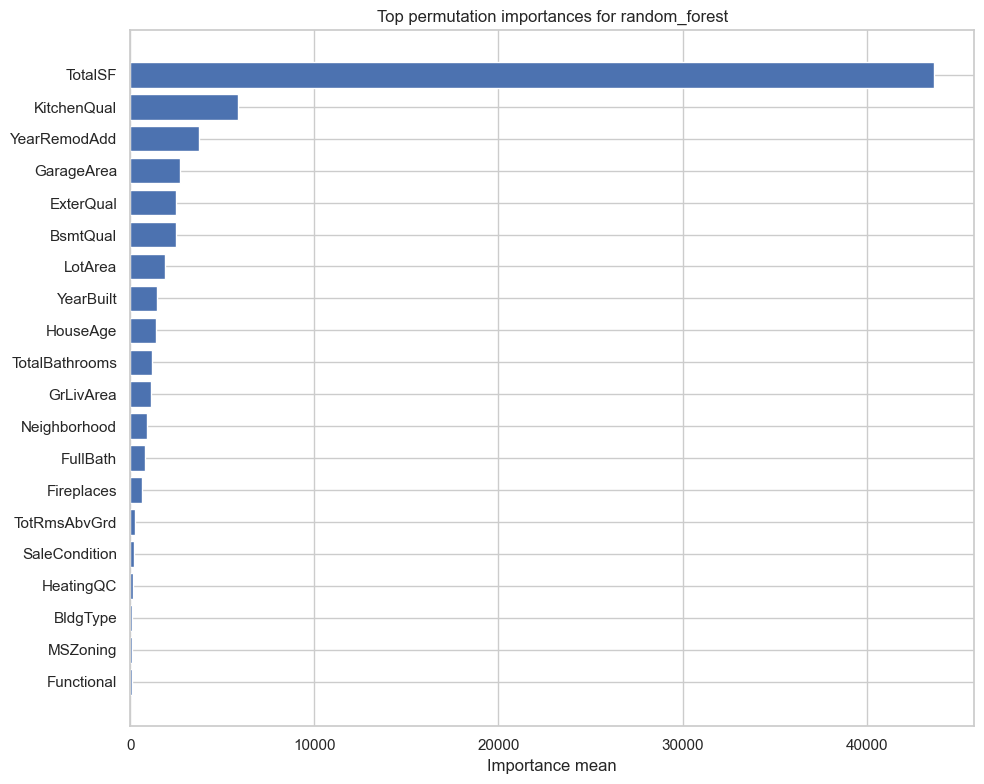

In [127]:
plt.figure(figsize=(10, 8))
plot_df = importance_df.head(20).sort_values('importance_mean')
plt.barh(plot_df['feature'], plot_df['importance_mean'])
plt.title(f'Top permutation importances for {best_model_name}')
plt.xlabel('Importance mean')
plt.tight_layout()

## 14. Manual review candidates

This final section helps turn the analysis into action. Instead of blindly dropping columns, create a short candidate list for the next experiment.


In [128]:
manual_review_candidates = {
    'skewed_numeric_candidates': candidate_log_features[:15],
    'top_permutation_features': importance_df.head(15)[['feature', 'importance_mean']].to_dict(orient='records'),
    'low_or_negative_importance_candidates': importance_df.loc[importance_df['importance_mean'] <= 0, 'feature'].head(15).tolist(),
    'unused_numeric_features': feature_selection_report['unused_numeric_features']['column'].tolist(),
    'unused_categorical_features': feature_selection_report['unused_categorical_features']['column'].tolist(),
    'unused_ordinal_features': feature_selection_report['unused_ordinal_features']['column'].tolist(),
}
manual_review_candidates

{'skewed_numeric_candidates': ['LotArea', 'HasGarage', 'TotalSF', 'GrLivArea'],
 'top_permutation_features': [{'feature': 'TotalSF',
   'importance_mean': 43657.33118497392},
  {'feature': 'KitchenQual', 'importance_mean': 5858.276882808727},
  {'feature': 'YearRemodAdd', 'importance_mean': 3735.2045052608755},
  {'feature': 'GarageArea', 'importance_mean': 2677.4852266470357},
  {'feature': 'ExterQual', 'importance_mean': 2466.2965209715835},
  {'feature': 'BsmtQual', 'importance_mean': 2460.6064534547304},
  {'feature': 'LotArea', 'importance_mean': 1854.3131807452748},
  {'feature': 'YearBuilt', 'importance_mean': 1454.25794602909},
  {'feature': 'HouseAge', 'importance_mean': 1414.4239610049294},
  {'feature': 'TotalBathrooms', 'importance_mean': 1169.9822074189035},
  {'feature': 'GrLivArea', 'importance_mean': 1134.4192637794715},
  {'feature': 'Neighborhood', 'importance_mean': 878.1079941217812},
  {'feature': 'FullBath', 'importance_mean': 765.9002393352733},
  {'feature': 'Fi

### Suggested next-step questions

- Which numeric features look skewed enough to justify a transform in the next experiment?
- Which categorical features show useful target separation even if their medians overlap?
- Which ordinal mappings should be rechecked because the target pattern does not look monotonic?
- Which unused features deserve a targeted experiment instead of staying excluded?
- Which low-importance features are truly weak, and which might only look weak because of redundancy?
